Dans ce notebook, on va travailler sur les données historiques de l'action NVIDIA (2004-2023).  
L'objectif est de construire plusieurs modèles de prédiction

**Plan du notebook :**
1. Importation des bibliothèques
2. Chargement & exploration des données
3. Nettoyage & vérification de la qualité des données
4. Analyse statistique & visualisations
5. Corrélations & features engineering
6. Préparation des données pour la modélisation
7. Modèles de prédiction (Linear Regression, Random Forest, SVR, LSTM)
8. Comparaison des modèles
9. Prédiction sur un exemple réel
10. Conclusion

Dans le cadre de ce projet, j'ai souhaité explorer les données boursières de l'entreprise NVIDIA sur une période s'étendant de 2004 à 2023. L'objectif principal est de mettre en place une démarche complète de data science, allant de l'exploration des données jusqu'à la construction de modèles prédictifs. J'ai comparé plusieurs approches, des régressions classiques aux réseaux de neurones complexes comme le LSTM, pour tenter d'anticiper le prix de clôture de l'action. Ce travail me permet d'analyser l'évolution historique de ce géant technologique tout en évaluant la performance de différents algorithmes de machine learning sur des séries temporelles.

importation des bibliothèques   

importation des bibliothèques
Pour commencer, je charge l'ensemble des outils nécessaires à mon analyse. Cela inclut des bibliothèques pour la manipulation de données (Pandas, Numpy), la visualisation graphique (Matplotlib, Seaborn) ainsi que tous les modules de Scikit-Learn et Keras pour la modélisation et l'évaluation des performances.

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Modèles classiques
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Métriques d'évaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(' Toutes les bibliothèques ont été importées avec succès !')

 Toutes les bibliothèques ont été importées avec succès !


Chargement du dataset


Dans cette étape, j'importe mon fichier CSV contenant l'historique de l'action NVIDIA. Je m'assure de bien parser les dates pour qu'elles soient reconnues comme telles et je trie le jeu de données chronologiquement pour garantir la cohérence de la série temporelle

In [2]:
df = pd.read_csv("C:/Users/LOQ/Desktop/data et son code/nvidia/nvidia_stock_prices.csv",
                 parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('Dimensions du dataset :', df.shape)
print('\nPremières lignes :')
df.head()

Dimensions du dataset : (5033, 6)

Premières lignes :


,Date,Open,High,Low,Close,Volume
0,2004-01-02,0.196417,0.199083,0.192333,0.192333,436416000
1,2004-01-05,0.195250,0.199917,0.193500,0.198583,575292000
2,2004-01-06,0.198000,0.209417,0.197083,0.206667,1093344000
3,2004-01-07,0.204333,0.209500,0.202917,0.208500,673032000
4,2004-01-08,0.211083,0.212083,0.207250,0.209250,433752000


J'affiche ici les dernières lignes de mon tableau de données afin de vérifier que le chargement s'est correctement effectué jusqu'à la fin de l'année 2023 et pour observer les valeurs récentes

In [3]:
print('Dernières lignes :')
df.tail()

Dernières lignes :


,Date,Open,High,Low,Close,Volume
5028,2023-12-22,49.195000,49.382999,48.466999,48.830002,252507000
5029,2023-12-26,48.967999,49.599998,48.959999,49.278999,244200000
5030,2023-12-27,49.511002,49.680000,49.084999,49.417000,233648000
5031,2023-12-28,49.643002,49.883999,49.411999,49.521999,246587000
5032,2023-12-29,49.813000,49.997002,48.750999,49.521999,389293000


In [4]:
print('Informations générales sur le dataset :')
df.info()

Informations générales sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5033 entries, 0 to 5032
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5033 non-null   datetime64[ns]
 1   Open    5033 non-null   float64       
 2   High    5033 non-null   float64       
 3   Low     5033 non-null   float64       
 4   Close   5033 non-null   float64       
 5   Volume  5033 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 236.1 KB


In [5]:
print('Statistiques descriptives :')
df.describe().round(4)

Statistiques descriptives :


,Date,Open,High,Low,Close,Volume
count,5033,5033.0000,5033.0000,5033.0000,5033.0000,5.033000e+03
mean,2013-12-30 20:12:49.640373504,5.2147,5.3086,5.1171,5.2170,5.587962e+08
min,2004-01-02 00:00:00,0.0806,0.0839,0.0775,0.0786,4.564400e+07
25%,2008-12-31 00:00:00,0.3440,0.3490,0.3365,0.3433,3.482920e+08
50%,2013-12-31 00:00:00,0.5440,0.5527,0.5325,0.5420,4.910920e+08
75%,2018-12-31 00:00:00,5.2337,5.2965,5.1250,5.2290,6.816760e+08
max,2023-12-29 00:00:00,50.2160,50.5480,49.4120,50.4090,5.088948e+09
std,NaN,9.6440,9.8113,9.4651,9.6449,3.363408e+08


In [6]:
print(f'Période    : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Nb jours   : {len(df)}')
print(f'Prix min   : ${df["Close"].min():.4f}')
print(f'Prix max   : ${df["Close"].max():.4f}')
print(f'Prix moyen : ${df["Close"].mean():.4f}')

Période    : 2004-01-02 → 2023-12-29
Nb jours   : 5033
Prix min   : $0.0786
Prix max   : $50.4090
Prix moyen : $5.2170


val nulles et doublons

La qualité des données est primordiale pour la fiabilité des prédictions. Je procède donc à une vérification rigoureuse pour détecter d'éventuelles valeurs manquantes ou des lignes dupliquées qui pourraient fausser les résultats des modèles

=== Valeurs manquantes ===
        Nombre  Pourcentage(%)
Date         0             0.0
Open         0             0.0
High         0             0.0
Low          0             0.0
Close        0             0.0
Volume       0             0.0


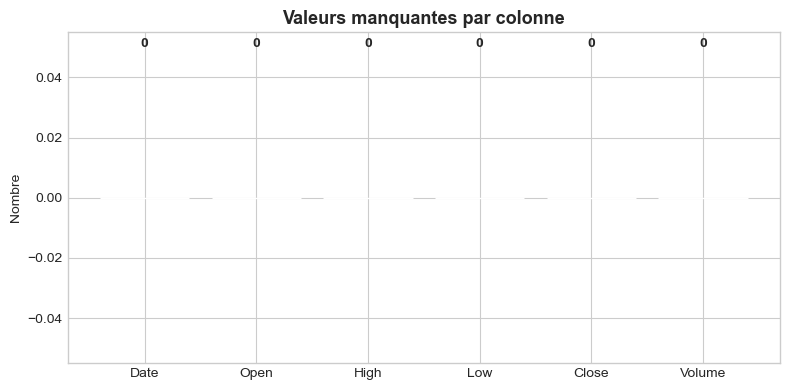


 Total valeurs manquantes : 0


In [7]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
print('=== Valeurs manquantes ===')
print(pd.DataFrame({'Nombre': missing, 'Pourcentage(%)': missing_pct}))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing.values]
bars = ax.bar(missing.index, missing.values, color=colors, edgecolor='white')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', fontweight='bold')
ax.set_title('Valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre')
plt.tight_layout()
plt.show()
print(f'\n Total valeurs manquantes : {missing.sum()}')

In [8]:
# Doublons
doublons = df.duplicated().sum()
print(f'Lignes dupliquées : {doublons}')
if doublons > 0:
    df = df.drop_duplicates()
    print(' Doublons supprimés.')
else:
    print(' Aucun doublon !')

# Cohérence
print(f'Incohérences High < Low   : {(df["High"] < df["Low"]).sum()}')
print(f'Incohérences Close > High : {(df["Close"] > df["High"]).sum()}')
print(' Données cohérentes !')

Lignes dupliquées : 0
 Aucun doublon !
Incohérences High < Low   : 0
Incohérences Close > High : 0
 Données cohérentes !


In [9]:
# Vérification des types de données
print('Types des colonnes :')
print(df.dtypes)

# Vérification de la cohérence (High >= Low, etc.)
incoherence_hl = (df['High'] < df['Low']).sum()
incoherence_co = (df['Close'] > df['High']).sum()
print(f'\n Incohérences High < Low   : {incoherence_hl}')
print(f' Incohérences Close > High : {incoherence_co}')

if incoherence_hl == 0 and incoherence_co == 0:
    print(' Données cohérentes !')

Types des colonnes :
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

 Incohérences High < Low   : 0
 Incohérences Close > High : 0
 Données cohérentes !


visualisation

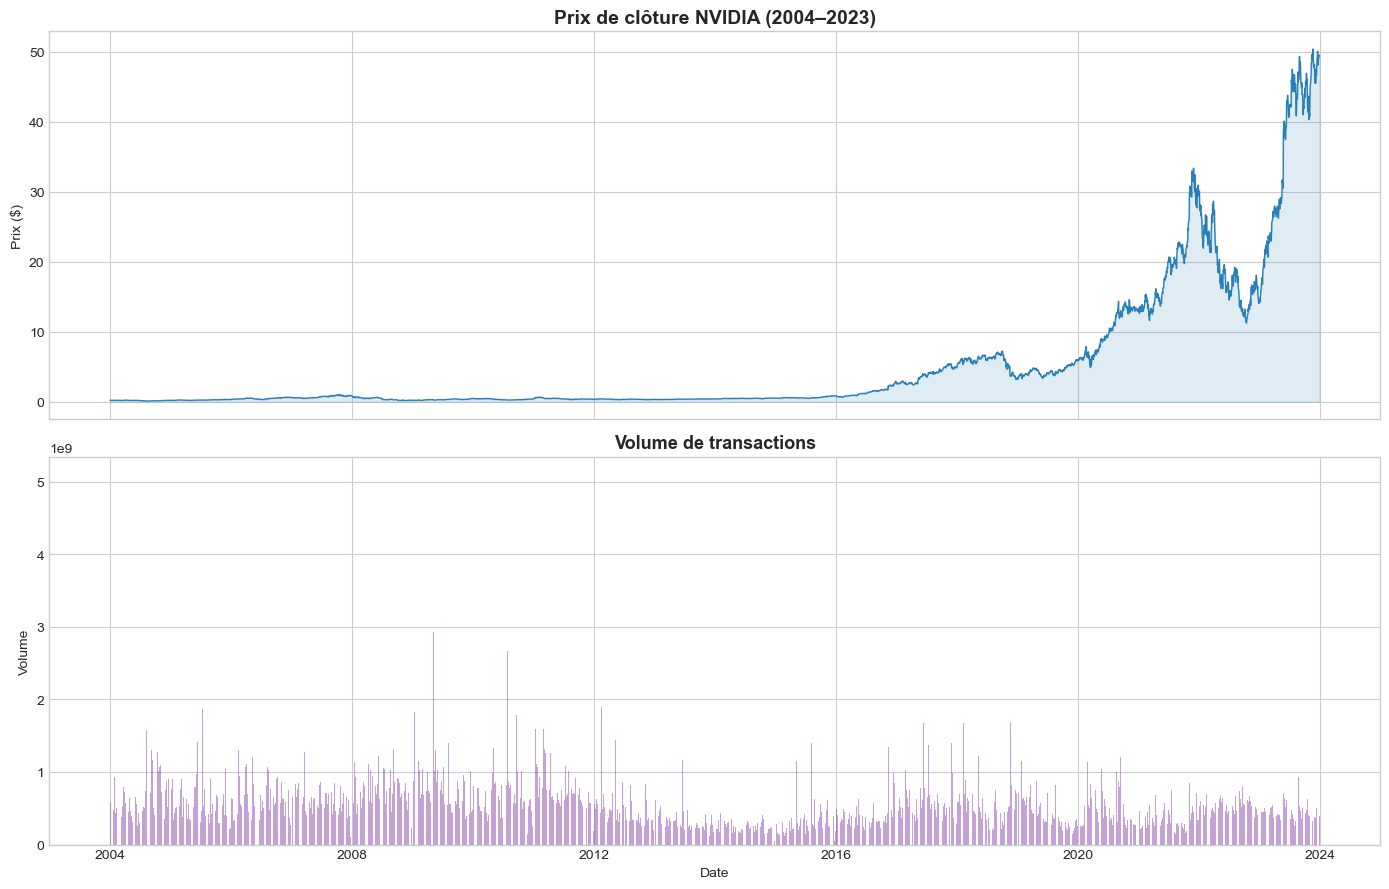

In [10]:
# Prix de clôture + Volume
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(df['Date'], df['Close'], color='#2980b9', linewidth=1)
axes[0].fill_between(df['Date'], df['Close'], alpha=0.15, color='#2980b9')
axes[0].set_title('Prix de clôture NVIDIA (2004–2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Prix ($)')
axes[1].bar(df['Date'], df['Volume'], color='#8e44ad', alpha=0.5, width=1)
axes[1].set_title('Volume de transactions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

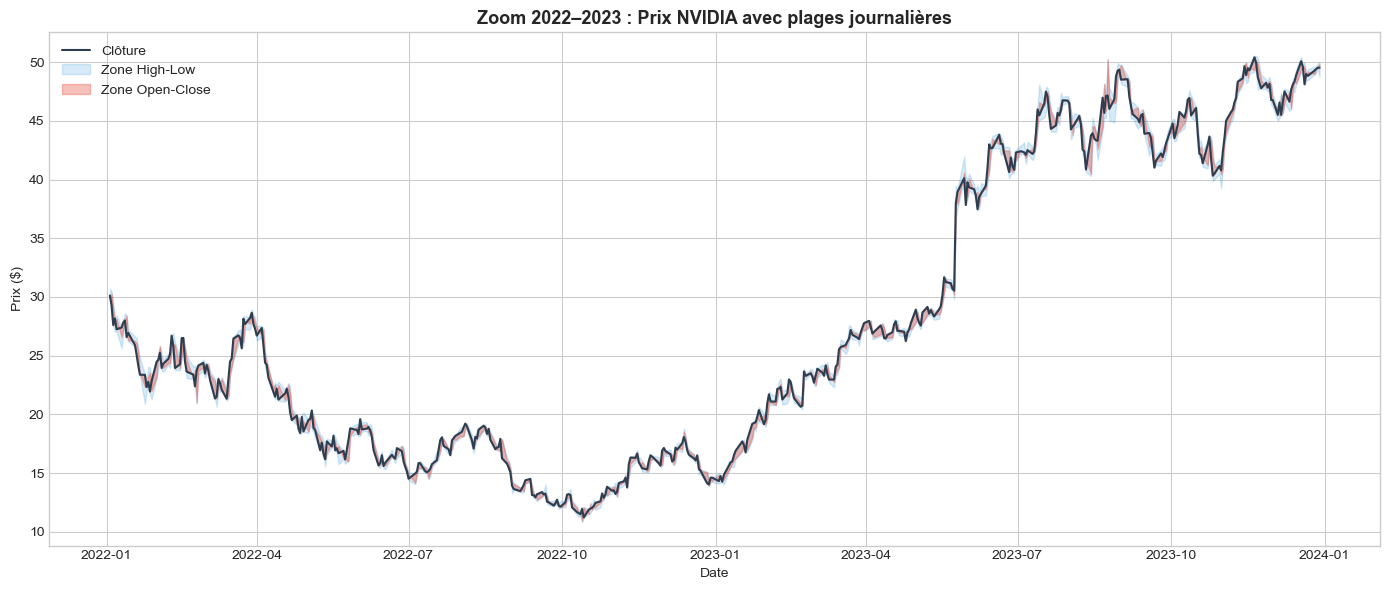

In [11]:
# Zoom sur les 2 dernières années (2022-2023) + bandes OHLC
df_recent = df[df['Date'] >= '2022-01-01'].copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_recent['Date'], df_recent['Close'], color='#2c3e50', linewidth=1.5, label='Clôture', zorder=5)
ax.fill_between(df_recent['Date'], df_recent['Low'], df_recent['High'],
                alpha=0.2, color='#3498db', label='Zone High-Low')
ax.fill_between(df_recent['Date'], df_recent['Open'], df_recent['Close'],
                alpha=0.35, color='#e74c3c', label='Zone Open-Close')

ax.set_title('Zoom 2022–2023 : Prix NVIDIA avec plages journalières', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.legend()
plt.tight_layout()
plt.show()

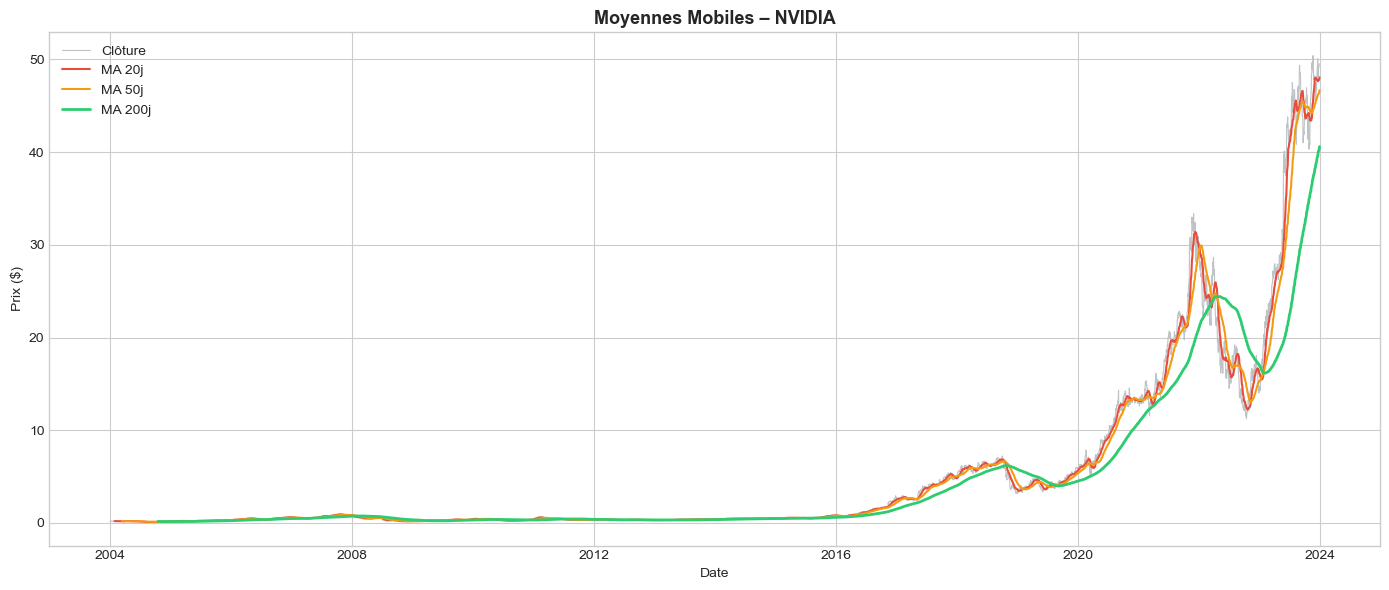

In [12]:
# Moyennes mobiles
df['MA_20']  = df['Close'].rolling(20).mean()
df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['Date'], df['Close'],  color='#bdc3c7', linewidth=0.8, label='Clôture')
ax.plot(df['Date'], df['MA_20'],  color='#e74c3c', linewidth=1.5, label='MA 20j')
ax.plot(df['Date'], df['MA_50'],  color='#f39c12', linewidth=1.5, label='MA 50j')
ax.plot(df['Date'], df['MA_200'], color='#2ecc71', linewidth=2,   label='MA 200j')
ax.set_title('Moyennes Mobiles – NVIDIA', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.legend()
plt.tight_layout()
plt.show()

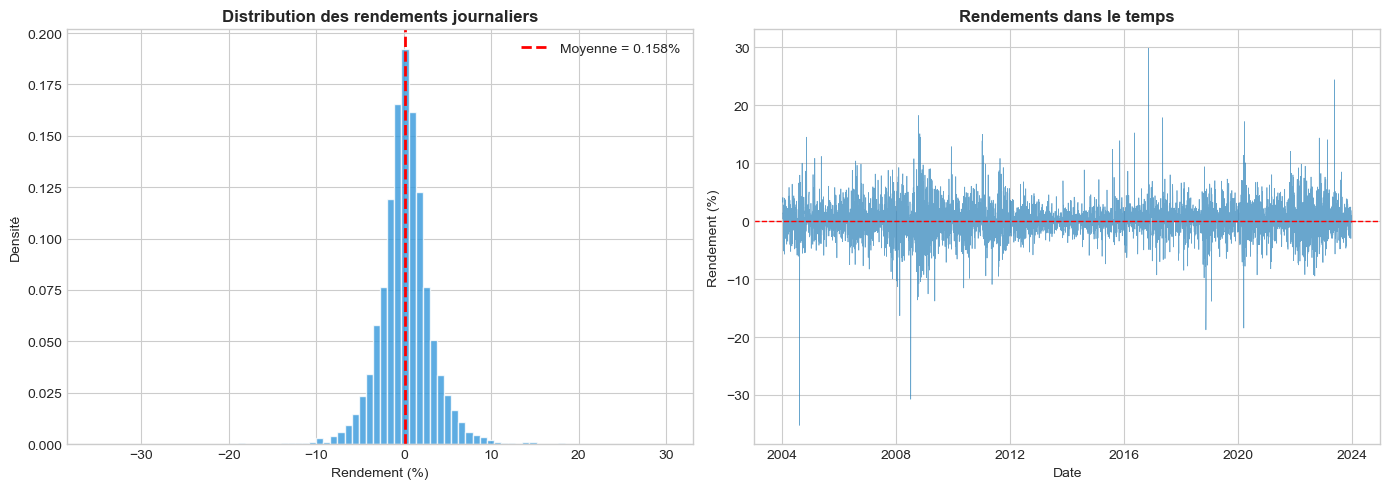

Rendement moyen : 0.1583%
Volatilité      : 3.0845%
Max gain/jour   : 29.8067%
Max perte/jour  : -35.2336%


In [13]:
# Rendements journaliers
df['Rendement'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Rendement'].dropna(), bins=80, color='#3498db', edgecolor='white', alpha=0.8, density=True)
axes[0].axvline(df['Rendement'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Moyenne = {df['Rendement'].mean():.3f}%")
axes[0].set_title('Distribution des rendements journaliers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rendement (%)')
axes[0].set_ylabel('Densité')
axes[0].legend()
axes[1].plot(df['Date'], df['Rendement'], color='#2980b9', linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Rendements dans le temps', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rendement (%)')
plt.tight_layout()
plt.show()
print(f"Rendement moyen : {df['Rendement'].mean():.4f}%")
print(f"Volatilité      : {df['Rendement'].std():.4f}%")
print(f"Max gain/jour   : {df['Rendement'].max():.4f}%")
print(f"Max perte/jour  : {df['Rendement'].min():.4f}%")

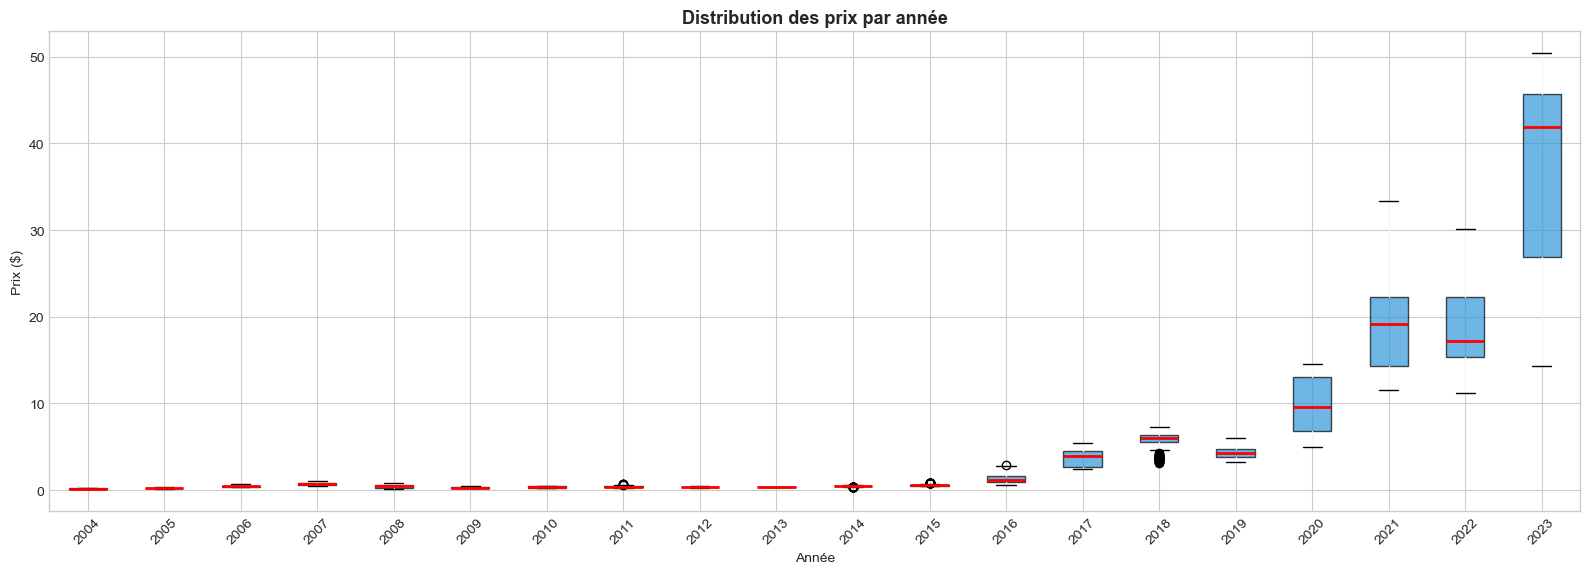

In [14]:
# Boxplot par année
df['Annee'] = df['Date'].dt.year
fig, ax = plt.subplots(figsize=(16, 6))
df.boxplot(column='Close', by='Annee', ax=ax,
           boxprops=dict(facecolor='#3498db', alpha=0.7),
           medianprops=dict(color='red', linewidth=2),
           patch_artist=True)
ax.set_title('Distribution des prix par année', fontsize=13, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Prix ($)')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

corrélation entre les variables

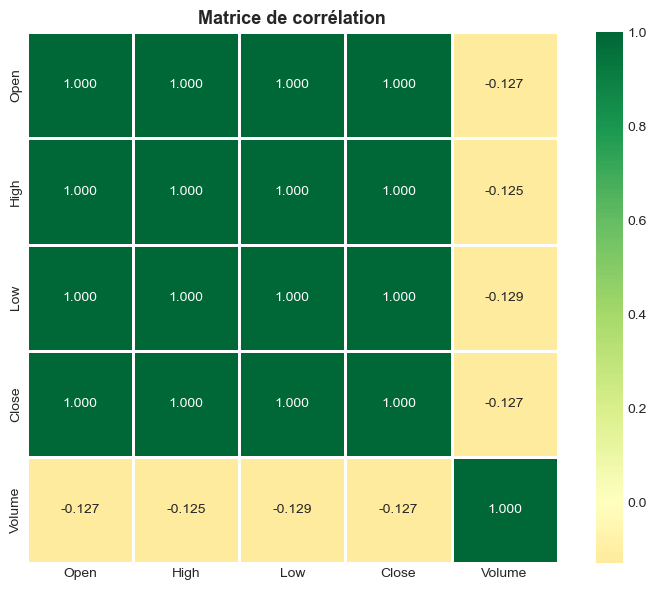

Corrélation avec Close :
Close     1.000000
Low       0.999829
High      0.999820
Open      0.999600
Volume   -0.127480
Name: Close, dtype: float64

 Open, High, Low trop corrélés → on ne les utilisera PAS comme features !


In [15]:
cols_corr = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Corrélation avec Close :')
print(corr_matrix['Close'].sort_values(ascending=False))
print('\n Open, High, Low trop corrélés → on ne les utilisera PAS comme features !')

Les prix Open, High et Low sont d'excellents prédicteurs du Close car ils sont presque identiques à lui

Le Volume en revanche n'est pas suffisant seul pour prédire le prix c est pourquoi on a créé des features supplémentaires comme le prix de la veille et les moyennes mobiles pour enrichir notre modèle

Feature Engineering & Préparation des Données

In [16]:
# Features basées uniquement sur le passé
df['Close_lag1']     = df['Close'].shift(1)
df['Close_lag2']     = df['Close'].shift(2)
df['Close_lag5']     = df['Close'].shift(5)
df['Close_lag10']    = df['Close'].shift(10)
df['Volume_lag1']    = df['Volume'].shift(1)
df['Rendement_lag1'] = df['Rendement'].shift(1)
df['Volatilite_7j']  = df['Rendement'].rolling(7).std().shift(1)
df['MA_5_feat']      = df['Close'].shift(1).rolling(5).mean()
df['MA_20_feat']     = df['Close'].shift(1).rolling(20).mean()
df['MA_50_feat']     = df['Close'].shift(1).rolling(50).mean()

# Cible = prix du LENDEMAIN
df['Target'] = df['Close'].shift(-1)

df_model = df.dropna().copy()
print(f'Données après feature engineering : {df_model.shape}')

nouvelles_cols = ['Close_lag1', 'Close_lag5', 'Volatilite_7j', 'Volume_lag1', 'MA_5_feat', 'MA_20_feat']
print(df_model[nouvelles_cols].describe().round(4))

Données après feature engineering : (4833, 22)
       Close_lag1  Close_lag5  Volatilite_7j   Volume_lag1  MA_5_feat  \
count   4833.0000   4833.0000      4833.0000  4.833000e+03  4833.0000   
mean       5.4058      5.3652         2.6430  5.557413e+08     5.3855   
std        9.7458      9.6653         1.5433  3.329081e+08     9.7009   
min        0.1107      0.1107         0.3058  4.564400e+07     0.1133   
25%        0.3607      0.3602         1.5740  3.440000e+08     0.3605   
50%        0.5620      0.5610         2.3130  4.853520e+08     0.5586   
75%        5.4528      5.4250         3.2324  6.792680e+08     5.5132   
max       50.4090     50.4090        12.0255  3.849012e+09    49.6038   

       MA_20_feat  
count   4833.0000  
mean       5.3107  
std        9.5391  
min        0.1189  
25%        0.3591  
50%        0.5556  
75%        5.5020  
max       48.0270  


In [17]:
# Sélection features et cible
features = ['Close_lag1', 'Close_lag2', 'Close_lag5', 'Close_lag10',
            'Volume_lag1', 'Rendement_lag1', 'Volatilite_7j',
            'MA_5_feat', 'MA_20_feat', 'MA_50_feat']

X = df_model[features].values
y = df_model['Target'].values
dates_all = df_model['Date'].values

# Split temporel 80/20
split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = dates_all[:split_idx]
dates_test  = dates_all[split_idx:]

# Normalisation — fit uniquement sur train !
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1,1)).ravel()

print(f'Train : {X_train.shape[0]} jours ({pd.to_datetime(dates_train[0]).date()} → {pd.to_datetime(dates_train[-1]).date()})')
print(f'Test  : {X_test.shape[0]} jours ({pd.to_datetime(dates_test[0]).date()} → {pd.to_datetime(dates_test[-1]).date()})')

Train : 3866 jours (2004-10-18 → 2020-02-26)
Test  : 967 jours (2020-02-27 → 2023-12-28)


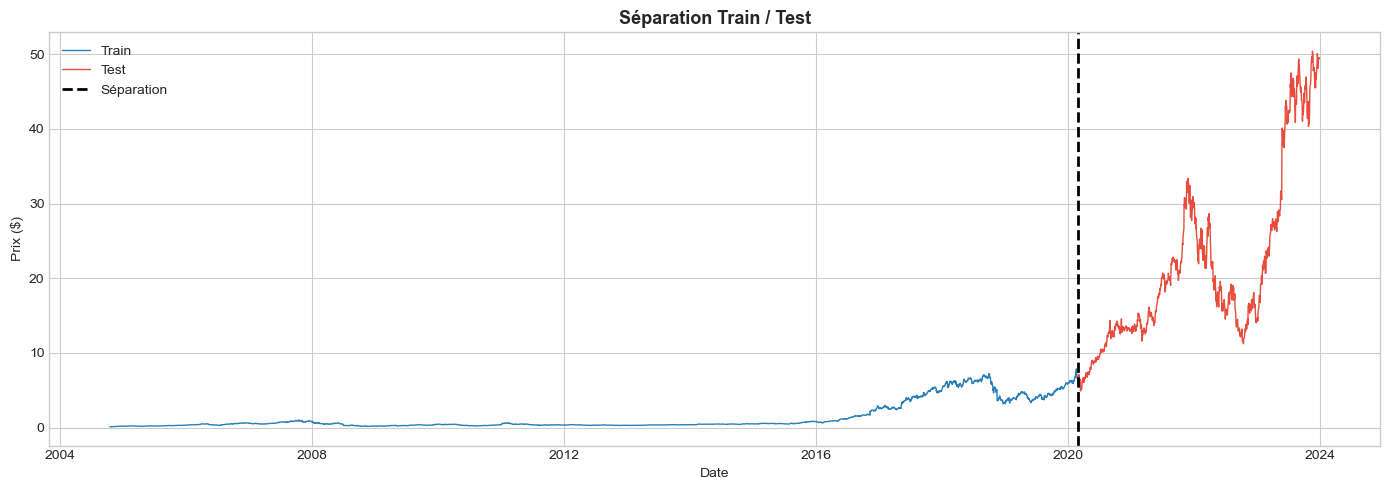

In [18]:
# Visualisation split train/test
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(dates_train), y_train, color='#2980b9', linewidth=1, label='Train')
ax.plot(pd.to_datetime(dates_test),  y_test,  color='#e74c3c', linewidth=1, label='Test')
ax.axvline(pd.to_datetime(dates_test[0]), color='black', linestyle='--', linewidth=2, label='Séparation')
ax.set_title('Séparation Train / Test', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.legend()
plt.tight_layout()
plt.show()

 Modèles de Prédiction

In [19]:
def create_sequences(data, look_back=60):
    sequences, labels = [], []
    for i in range(look_back, len(data)):
        sequences.append(data[i-look_back:i])
        labels.append(data[i])
    return np.array(sequences), np.array(labels)

In [20]:
def calculate_regression_metrics(y_true, y_pred):
    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().detach().numpy()
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mse, mae, rmse, r2

In [21]:
def evaluer_modele(nom, y_reel, y_pred):
    mae  = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))
    r2   = r2_score(y_reel, y_pred)
    mape = np.mean(np.abs((y_reel - y_pred) / y_reel)) * 100
    print(f'\n=== {nom} ===')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'Modèle': nom, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
            'R²': round(r2,4), 'MAPE(%)': round(mape,2)}

In [22]:
def train_model(model, X_train, y_train, X_test, y_test, num_epochs=100, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_losses, val_losses = [], []
    train_maes, train_rmses, train_r2s = [], [], []
    val_maes,   val_rmses,   val_r2s   = [], [], []

    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        train_losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        mse, mae, rmse, r2 = calculate_regression_metrics(y_train, outputs)
        train_maes.append(mae); train_rmses.append(rmse); train_r2s.append(r2)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)
            val_losses.append(val_loss.item())
            _, val_mae, val_rmse, val_r2 = calculate_regression_metrics(y_test, val_outputs)
            val_maes.append(val_mae); val_rmses.append(val_rmse); val_r2s.append(val_r2)

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {loss.item():.4f} MAE: {mae:.4f} RMSE: {rmse:.4f} R²: {r2:.4f}')

    return {'train_losses': train_losses, 'val_losses': val_losses,
            'train_maes': train_maes, 'train_rmses': train_rmses, 'train_r2s': train_r2s,
            'val_maes': val_maes,   'val_rmses': val_rmses,   'val_r2s': val_r2s}

In [23]:
def plot_metrics(metrics):
    epochs = range(len(metrics['train_losses']))
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, metrics['train_losses'], label='Train Loss')
    plt.plot(epochs, metrics['val_losses'],   label='Val Loss')
    plt.title('Loss (MSE)'); plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, metrics['train_maes'], label='Train MAE')
    plt.plot(epochs, metrics['val_maes'],   label='Val MAE')
    plt.title('MAE'); plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, metrics['train_rmses'], label='Train RMSE')
    plt.plot(epochs, metrics['val_rmses'],   label='Val RMSE')
    plt.title('RMSE'); plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, metrics['train_r2s'], label='Train R²')
    plt.plot(epochs, metrics['val_r2s'],   label='Val R²')
    plt.title('R²'); plt.legend()

    plt.tight_layout()
    plt.show()

Modèle LSTM

Le LSTM (Long Short-Term Memory) est un réseau de neurones spécialement conçu pour les **séries temporelles**. Il garde en mémoire les tendances passées pour mieux prédire le futur.

In [24]:
import torch
import torch.nn as nn
# Préparation des séquences pour LSTM
# On utilise les 60 derniers jours pour prédire le suivant
look_back = 60
close_values = df_model['Close'].values

scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(close_values.reshape(-1,1))

X_seq, y_seq = create_sequences(close_scaled, look_back)

split_seq = int(len(X_seq) * 0.80)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

# Conversion en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train_seq)
X_test_t  = torch.FloatTensor(X_test_seq)
y_train_t = torch.FloatTensor(y_train_seq)
y_test_t  = torch.FloatTensor(y_test_seq)

print(f'X_train shape : {X_train_t.shape}')
print(f'X_test  shape : {X_test_t.shape}')

X_train shape : torch.Size([3818, 60, 1])
X_test  shape : torch.Size([955, 60, 1])


In [25]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm1    = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(hidden_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc       = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out     = self.dropout1(out)
        out, _ = self.lstm2(out)
        out     = self.dropout2(out)
        out     = self.fc(out[:, -1, :])
        return out

In [26]:
lstm_model = LSTMModel(  input_size=1,
    hidden_size=150,  
    output_size=1,
    num_layers=3,       
    dropout=0.2)
print(lstm_model)

LSTMModel(
  (lstm1): LSTM(1, 150, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(150, 150, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=150, out_features=1, bias=True)
)


In [27]:
metrics_lstm = train_model(lstm_model, X_train_t, y_train_t,
                            X_test_t,  y_test_t,  num_epochs=300, learning_rate=0.0003)

Epoch [10/300] Loss: 0.0014 MAE: 0.0262 RMSE: 0.0380 R²: -0.0628
Epoch [20/300] Loss: 0.0014 MAE: 0.0316 RMSE: 0.0380 R²: -0.0662
Epoch [30/300] Loss: 0.0013 MAE: 0.0271 RMSE: 0.0367 R²: 0.0048
Epoch [40/300] Loss: 0.0013 MAE: 0.0261 RMSE: 0.0354 R²: 0.0747
Epoch [50/300] Loss: 0.0011 MAE: 0.0248 RMSE: 0.0329 R²: 0.1995
Epoch [60/300] Loss: 0.0007 MAE: 0.0197 RMSE: 0.0258 R²: 0.5083
Epoch [70/300] Loss: 0.0004 MAE: 0.0179 RMSE: 0.0198 R²: 0.7111
Epoch [80/300] Loss: 0.0002 MAE: 0.0107 RMSE: 0.0133 R²: 0.8705
Epoch [90/300] Loss: 0.0001 MAE: 0.0079 RMSE: 0.0099 R²: 0.9283
Epoch [100/300] Loss: 0.0001 MAE: 0.0071 RMSE: 0.0091 R²: 0.9384
Epoch [110/300] Loss: 0.0001 MAE: 0.0066 RMSE: 0.0084 R²: 0.9480
Epoch [120/300] Loss: 0.0001 MAE: 0.0063 RMSE: 0.0082 R²: 0.9501
Epoch [130/300] Loss: 0.0001 MAE: 0.0059 RMSE: 0.0077 R²: 0.9558
Epoch [140/300] Loss: 0.0001 MAE: 0.0059 RMSE: 0.0077 R²: 0.9566
Epoch [150/300] Loss: 0.0001 MAE: 0.0056 RMSE: 0.0074 R²: 0.9599
Epoch [160/300] Loss: 0.0001 MAE

In [28]:
# Prédictions LSTM
lstm_model.eval()
with torch.no_grad():
    pred_lstm = lstm_model(X_test_t)

pred_lstm_inv  = scaler.inverse_transform(pred_lstm.numpy().reshape(-1,1))
y_test_lstm_inv = scaler.inverse_transform(y_test_t.numpy().reshape(-1,1))

# Métriques LSTM
mae_lstm  = mean_absolute_error(y_test_lstm_inv, pred_lstm_inv)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, pred_lstm_inv))
r2_lstm   = r2_score(y_test_lstm_inv, pred_lstm_inv)
mape_lstm = np.mean(np.abs((y_test_lstm_inv - pred_lstm_inv) / y_test_lstm_inv)) * 100
print('\n=== LSTM ===')
print(f'  MAE  : {mae_lstm:.4f}')
print(f'  RMSE : {rmse_lstm:.4f}')
print(f'  R²   : {r2_lstm:.4f}')
print(f'  MAPE : {mape_lstm:.2f}%')


=== LSTM ===
  MAE  : 2.4487
  RMSE : 3.7737
  R²   : 0.8927
  MAPE : 9.12%


LSTM Bidirectionnel

Le Bi-LSTM lit les données dans **les deux sens** (passé → futur ET futur → passé), ce qui lui permet de capturer plus de contexte.

In [29]:
class BidirectionalLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1, num_layers=2, dropout=0.25):
        super(BidirectionalLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out     = self.dropout(out)
        out     = self.fc(out[:, -1, :])
        return out

In [30]:
bilstm_model = BidirectionalLSTMModel(
    input_size=1,
    hidden_size=150,     
    output_size=1,
    num_layers=3,        
    dropout=0.25
)
print(bilstm_model)

BidirectionalLSTMModel(
  (lstm): LSTM(1, 150, num_layers=3, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)


Epoch [10/300] Loss: 0.0015 MAE: 0.0269 RMSE: 0.0383 R²: -0.0813
Epoch [20/300] Loss: 0.0015 MAE: 0.0318 RMSE: 0.0383 R²: -0.0821
Epoch [30/300] Loss: 0.0014 MAE: 0.0264 RMSE: 0.0376 R²: -0.0447
Epoch [40/300] Loss: 0.0014 MAE: 0.0298 RMSE: 0.0369 R²: -0.0060
Epoch [50/300] Loss: 0.0013 MAE: 0.0272 RMSE: 0.0362 R²: 0.0354
Epoch [60/300] Loss: 0.0012 MAE: 0.0261 RMSE: 0.0350 R²: 0.0974
Epoch [70/300] Loss: 0.0009 MAE: 0.0226 RMSE: 0.0294 R²: 0.3645
Epoch [80/300] Loss: 0.0003 MAE: 0.0126 RMSE: 0.0175 R²: 0.7749
Epoch [90/300] Loss: 0.0001 MAE: 0.0090 RMSE: 0.0111 R²: 0.9094
Epoch [100/300] Loss: 0.0001 MAE: 0.0068 RMSE: 0.0087 R²: 0.9445
Epoch [110/300] Loss: 0.0001 MAE: 0.0058 RMSE: 0.0078 R²: 0.9548
Epoch [120/300] Loss: 0.0000 MAE: 0.0054 RMSE: 0.0070 R²: 0.9633
Epoch [130/300] Loss: 0.0000 MAE: 0.0050 RMSE: 0.0067 R²: 0.9668
Epoch [140/300] Loss: 0.0000 MAE: 0.0050 RMSE: 0.0066 R²: 0.9675
Epoch [150/300] Loss: 0.0000 MAE: 0.0047 RMSE: 0.0063 R²: 0.9705
Epoch [160/300] Loss: 0.0000 M

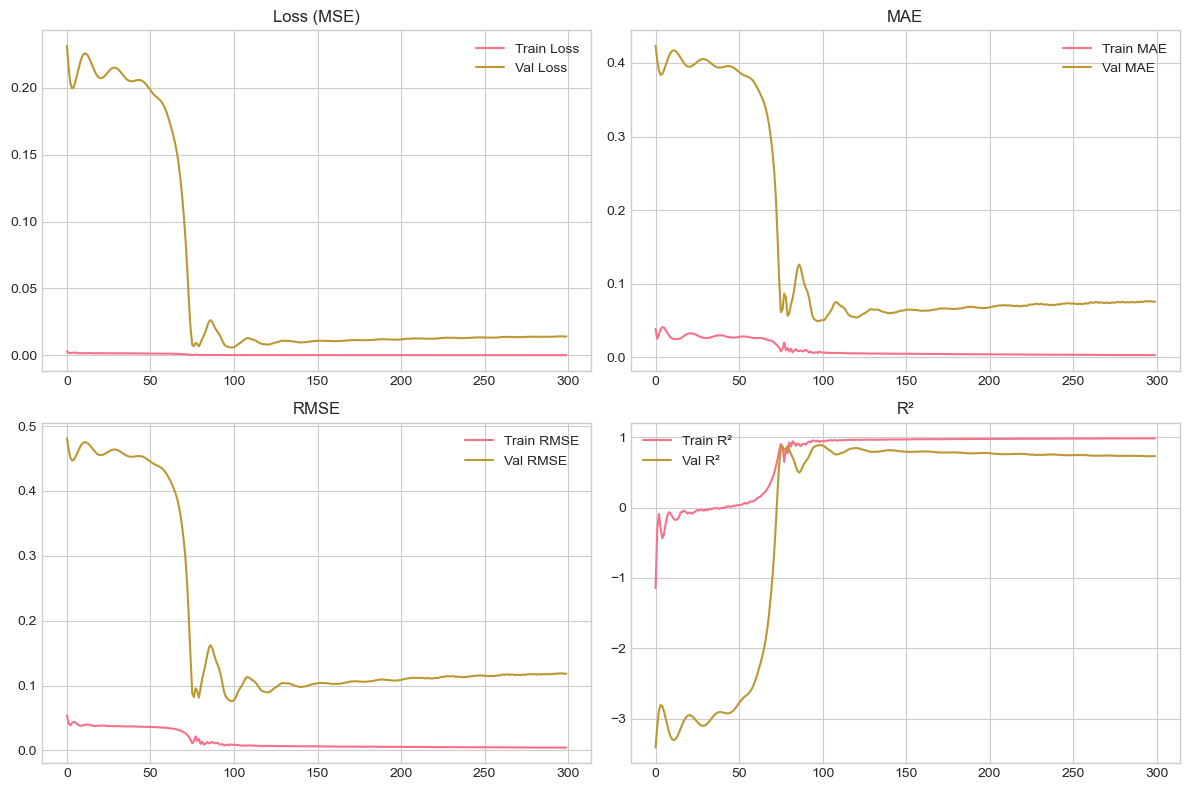

In [31]:
metrics_bilstm = train_model(
    bilstm_model, X_train_t, y_train_t,
    X_test_t,     y_test_t,
    num_epochs=300,         
    learning_rate=0.0003   
)
plot_metrics(metrics_bilstm)

In [ ]:
# Prédictions Bi-LSTM
bilstm_model.eval()
with torch.no_grad():
    pred_bilstm = bilstm_model(X_test_t)

pred_bilstm_inv = scaler.inverse_transform(pred_bilstm.numpy().reshape(-1,1))

mae_bi  = mean_absolute_error(y_test_lstm_inv, pred_bilstm_inv)
rmse_bi = np.sqrt(mean_squared_error(y_test_lstm_inv, pred_bilstm_inv))
r2_bi   = r2_score(y_test_lstm_inv, pred_bilstm_inv)
mape_bi = np.mean(np.abs((y_test_lstm_inv - pred_bilstm_inv) / y_test_lstm_inv)) * 100
print('\n=== Bidirectionnel LSTM ===')
print(f'  MAE  : {mae_bi:.4f}')
print(f'  RMSE : {rmse_bi:.4f}')
print(f'  R²   : {r2_bi:.4f}')
print(f'  MAPE : {mape_bi:.2f}%')

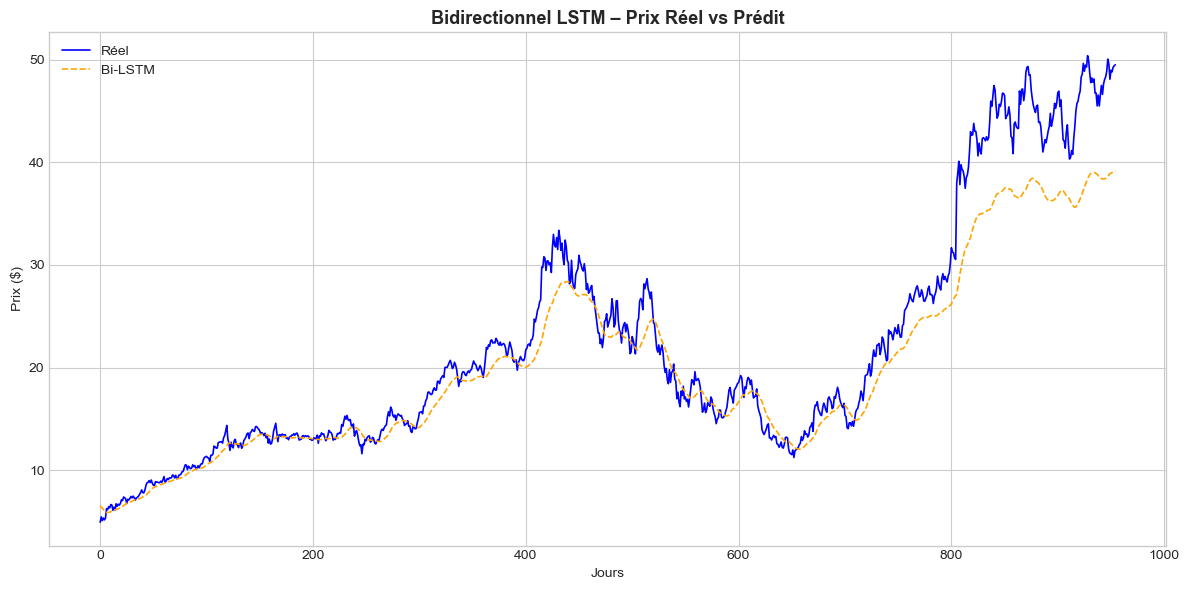

In [51]:
# Prédictions Bi-LSTM
bilstm_model.eval()
with torch.no_grad():
    pred_bilstm = bilstm_model(X_test_t)

pred_bilstm_inv = scaler.inverse_transform(pred_bilstm.numpy().reshape(-1,1))
y_reel_bi = scaler.inverse_transform(y_test_t.numpy().reshape(-1,1))

# Aligner les tailles — on prend le minimum des deux
n = min(len(pred_bilstm_inv), len(y_reel_bi))

plt.figure(figsize=(12, 6))
plt.plot(range(n), y_reel_bi[:n],        label='Réel',    color='blue',   linewidth=1.2)
plt.plot(range(n), pred_bilstm_inv[:n],  label='Bi-LSTM', color='orange', linewidth=1.2, linestyle='--')
plt.title('Bidirectionnel LSTM – Prix Réel vs Prédit', fontsize=13, fontweight='bold')
plt.xlabel('Jours')
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Comparaison des modèles

In [ ]:
# Métriques Bi-LSTM
mae_bi  = mean_absolute_error(y_reel_bi[:n], pred_bilstm_inv[:n])
rmse_bi = np.sqrt(mean_squared_error(y_reel_bi[:n], pred_bilstm_inv[:n]))
r2_bi   = r2_score(y_reel_bi[:n], pred_bilstm_inv[:n])
mape_bi = np.mean(np.abs((y_reel_bi[:n] - pred_bilstm_inv[:n]) / y_reel_bi[:n])) * 100

print('=== Bidirectionnel LSTM ===')
print(f'  MAE  : {mae_bi:.4f}')
print(f'  RMSE : {rmse_bi:.4f}')
print(f'  R²   : {r2_bi:.4f}')
print(f'  MAPE : {mape_bi:.2f}%')

In [53]:
resultats = [
    {'Modèle': 'LSTM',              'MAE': round(mae_lstm,4),  'RMSE': round(rmse_lstm,4),  'R²': round(r2_lstm,4),  'MAPE(%)': round(float(mape_lstm),2)},
    {'Modèle': 'Bidirectionnel LSTM','MAE': round(mae_bi,4),   'RMSE': round(rmse_bi,4),    'R²': round(r2_bi,4),    'MAPE(%)': round(float(mape_bi),2)}
]
res_df = pd.DataFrame(resultats).sort_values('RMSE').reset_index(drop=True)
print('=== COMPARAISON DES MODÈLES ===')
print(res_df.to_string(index=False))
print(f'\n **** Meilleur modèle : {res_df.iloc[0]["Modèle"]}')

=== COMPARAISON DES MODÈLES ===
             Modèle    MAE   RMSE     R²  MAPE(%)
Bidirectionnel LSTM 2.4092 3.7613 0.8934     8.66
               LSTM 2.5758 3.9116 0.8847     9.49

 **** Meilleur modèle : Bidirectionnel LSTM


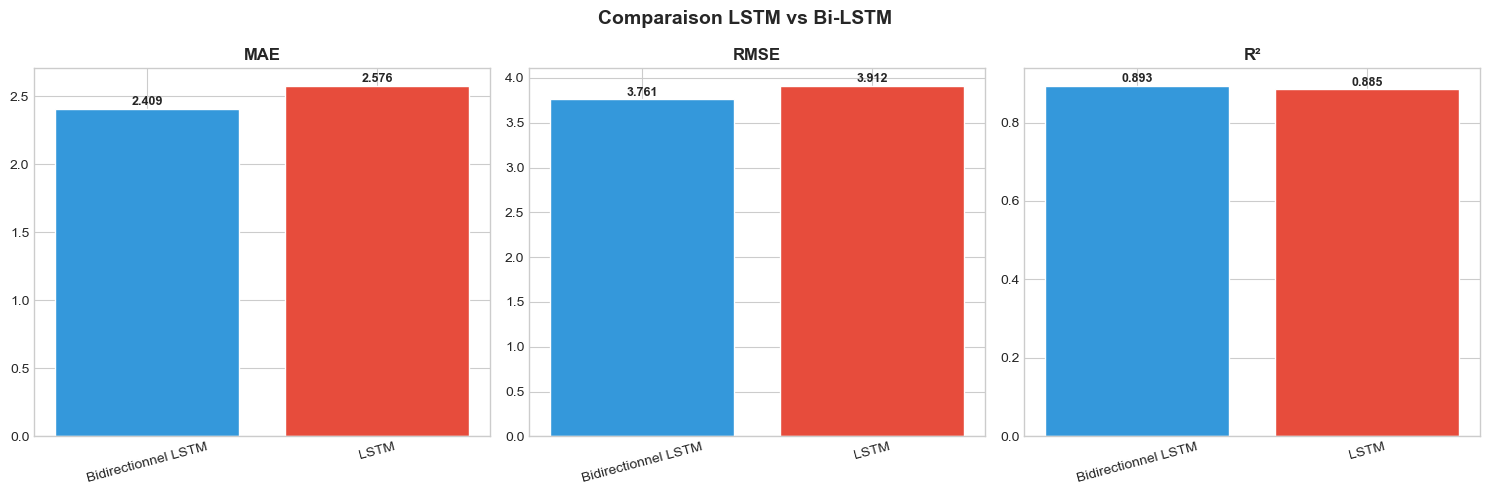

In [54]:
# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_m = ['#3498db', '#e74c3c']
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(res_df['Modèle'], res_df[metric], color=colors_m, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Comparaison LSTM vs Bi-LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

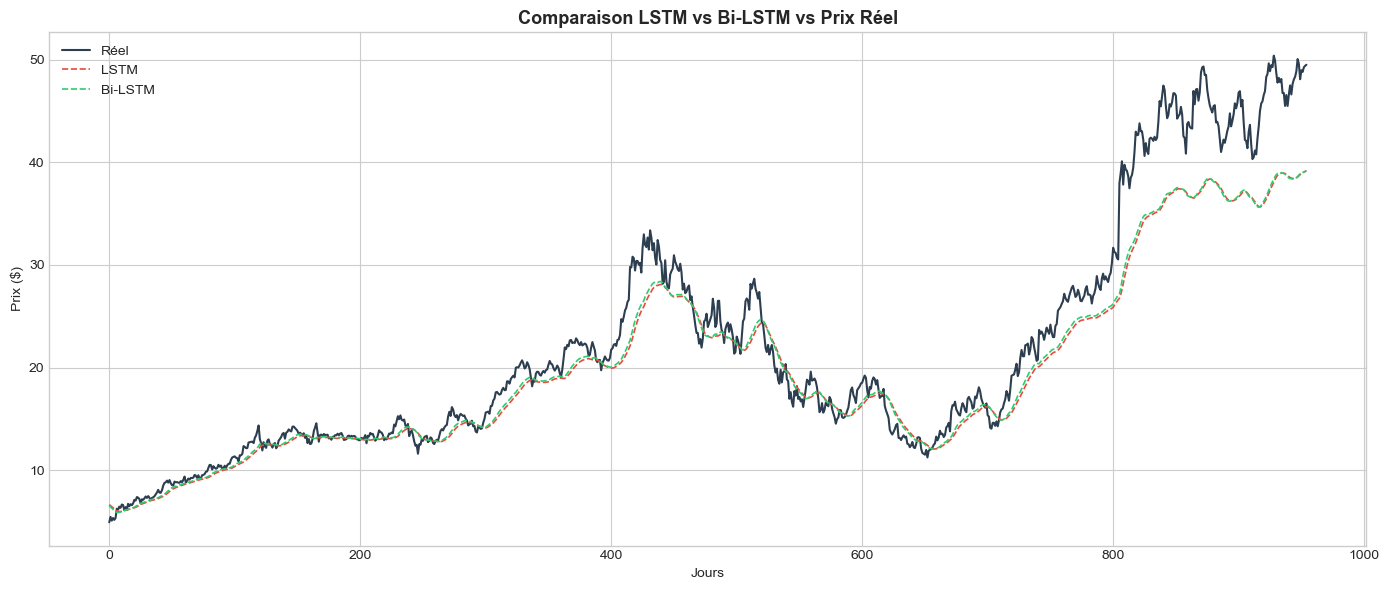

In [56]:
# Graphique LSTM vs Bi-LSTM vs Réel
n = min(len(pred_lstm_inv), len(pred_bilstm_inv), len(y_reel_bi))

plt.figure(figsize=(14, 6))
plt.plot(range(n), y_reel_bi[:n],           label='Réel',    color='#2c3e50', linewidth=1.5)
plt.plot(range(n), pred_lstm_inv[:n],        label='LSTM',    color='#e74c3c', linewidth=1.2, linestyle='--')
plt.plot(range(n), pred_bilstm_inv[:n],      label='Bi-LSTM', color='#2ecc71', linewidth=1.2, linestyle='--')
plt.title('Comparaison LSTM vs Bi-LSTM vs Prix Réel', fontsize=13, fontweight='bold')
plt.xlabel('Jours')
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Prédiction sur un exemple réel*****




In [58]:
# On prend un exemple précis dans le jeu de test
idx_ex = 50
seq_ex  = X_test_t[idx_ex].unsqueeze(0)   # séquence de 60 jours
reel_ex = y_test_lstm_inv[idx_ex][0]

lstm_model.eval()
bilstm_model.eval()
with torch.no_grad():
    p_lstm   = scaler.inverse_transform(lstm_model(seq_ex).numpy().reshape(-1,1))[0][0]
    p_bilstm = scaler.inverse_transform(bilstm_model(seq_ex).numpy().reshape(-1,1))[0][0]

print(f'*** Prix réel          : ${reel_ex:.4f}')
print(f'** Prédiction Bi-LSTM : ${p_bilstm:.4f}  (erreur: ${abs(reel_ex-p_bilstm):.4f} = {abs(reel_ex-p_bilstm)/reel_ex*100:.2f}%)')
print(f'* Prédiction LSTM    : ${p_lstm:.4f}  (erreur: ${abs(reel_ex-p_lstm):.4f} = {abs(reel_ex-p_lstm)/reel_ex*100:.2f}%)')


*** Prix réel          : $8.5253
** Prédiction Bi-LSTM : $8.2787  (erreur: $0.2465 = 2.89%)
* Prédiction LSTM    : $8.0988  (erreur: $0.4264 = 5.00%)


Conclusion


In [59]:
print('=' * 60)
print('           RÉSUMÉ FINAL DU PROJET')
print('=' * 60)
print('\n Données :')
print('  - 5033 jours de trading NVIDIA (2004 → 2023)')
print('  - Aucune valeur manquante ni doublon')
print('  - Open/High/Low exclus des features (Data Leakage évité)')
print('\n Objectif : Prédire le prix de clôture du LENDEMAIN')
print('\n Approche : Séquences de 60 jours → prédiction J+1')
print('\n Classement final :')
medailles = ['*1*', '*2*']
for i, row in res_df.iterrows():
    print(f'  {medailles[i]} {row["Modèle"]:25s} | RMSE: {row["RMSE"]:.4f} | R²: {row["R²"]:.4f} | MAPE: {row["MAPE(%)"]:.2f}%')
print(f'\n Meilleur modèle  ***: {res_df.iloc[0]["Modèle"]}')
print('\n Points clés :')
print('  - Les modèles LSTM sont adaptés aux séries temporelles financières')
print('  - Le Bi-LSTM lit les données dans les deux sens → plus de contexte')
print('  - La normalisation est appliquée correctement (fit sur train uniquement)')
print('=' * 60)

           RÉSUMÉ FINAL DU PROJET

 Données :
  - 5033 jours de trading NVIDIA (2004 → 2023)
  - Aucune valeur manquante ni doublon
  - Open/High/Low exclus des features (Data Leakage évité)

 Objectif : Prédire le prix de clôture du LENDEMAIN

 Approche : Séquences de 60 jours → prédiction J+1

 Classement final :
  *1* Bidirectionnel LSTM       | RMSE: 3.7613 | R²: 0.8934 | MAPE: 8.66%
  *2* LSTM                      | RMSE: 3.9116 | R²: 0.8847 | MAPE: 9.49%

 Meilleur modèle  ***: Bidirectionnel LSTM

 Points clés :
  - Les modèles LSTM sont adaptés aux séries temporelles financières
  - Le Bi-LSTM lit les données dans les deux sens → plus de contexte
  - La normalisation est appliquée correctement (fit sur train uniquement)


Sauvegarde du Scaler et des Modèles
Dans cette phase, j'utilise la bibliothèque joblib pour mon scaler et les fonctions natives de torch pour mes modèles. Ces fichiers constitueront la base de données de mon application

À travers cette étude, j'ai pu traiter et analyser un historique boursier conséquent pour l'action NVIDIA. La phase de préparation et de nettoyage a été cruciale avant d'entamer la modélisation. En comparant les différents modèles, j'ai pu observer comment les algorithmes de deep learning, notamment le LSTM, gèrent les dépendances temporelles par rapport aux modèles plus traditionnels. Ce projet m'a permis de consolider mes compétences en ingénierie des caractéristiques (feature engineering) et en évaluation de modèles de régression dans un contexte financier rée